# Machine Learning Exercise 4
by Thanh Tran, Gero Brunke, Robin-Marcel Hanne

In [52]:
import numpy as np
from scipy.sparse import coo_matrix
import matplotlib.pyplot as plt
from scipy.sparse.linalg import lsqr

In [53]:
def construct_X(M, alphas, Np=None):
    alphas = np.asarray(alphas)
    No = len(alphas)

    if Np is None:
        Np = int(np.ceil(np.sqrt(2) * M))
        if Np % 2 == 0:
            Np += 1

    D = M * M
    N = No * Np

    center = (M - 1) / 2

    ja, jb = np.mgrid[0:M, 0:M]
    a = ja - center
    b = jb - center

    C = np.vstack([a.ravel(), b.ravel()])
    pixels = np.arange(D)

    s0 = (Np - 1) / 2

    i_indices = []
    j_indices = []
    weights = []

    for io, alpha in enumerate(alphas):

        theta = np.deg2rad(alpha)

        n = np.array([-np.sin(theta), np.cos(theta)])

        p = n @ C + s0

        k = np.floor(p).astype(np.int32)
        w = p - k

        offset = io * Np

        m1 = (k >= 0) & (k < Np)
        i_indices.append(offset + k[m1])
        j_indices.append(pixels[m1])
        weights.append((1 - w[m1]).astype(np.float32))

        m2 = (k + 1 >= 0) & (k + 1 < Np)
        i_indices.append(offset + k[m2] + 1)
        j_indices.append(pixels[m2])
        weights.append(w[m2].astype(np.float32))

    i_indices = np.concatenate(i_indices)
    j_indices = np.concatenate(j_indices)
    weights = np.concatenate(weights)

    return coo_matrix((weights, (i_indices, j_indices)), shape=(N, D), dtype=np.float32)

In [54]:
folder = "hs_tomography/"

y_77 = np.load(folder + "y_77.npy")
alphas_77 = np.load(folder + "alphas_77.npy")

y_195 = np.load(folder + "y_195.npy")
alphas_195 = np.load(folder + "alphas_195.npy")

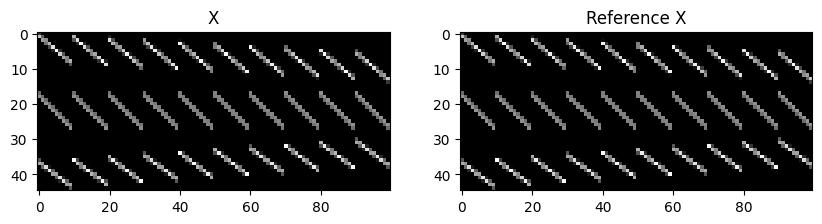

In [55]:
X_test = construct_X(10, [-33, 1, 42])
X_ref = np.load(folder + "X_example.npy")

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("X")
plt.imshow(X_test.toarray(), cmap="gray")

plt.subplot(1,2,2)
plt.title("Reference X")
plt.imshow(X_ref, cmap="gray")

plt.show()

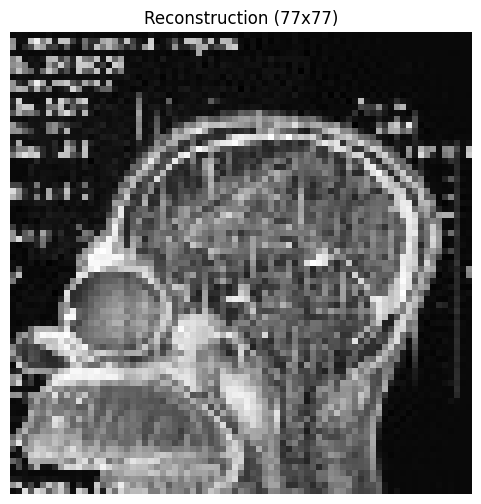

In [56]:
X_77 = construct_X(77, alphas_77, Np=109)

beta_77 = lsqr(X_77.tocsc(), y_77)[0]
img_77 = beta_77.reshape((77, 77))

plt.figure(figsize=(6,6))
plt.imshow(img_77, cmap="gray")
plt.title("Reconstruction (77x77)")
plt.axis("off")
plt.show()

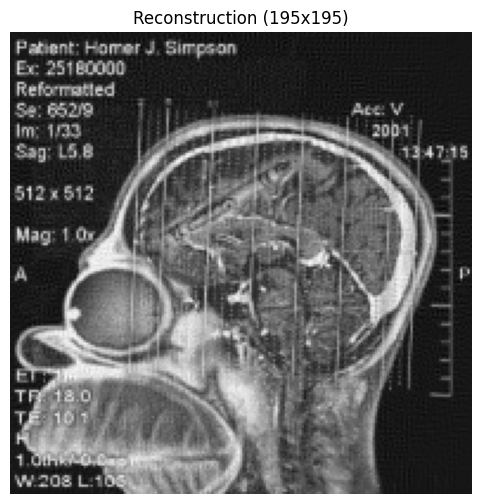

In [57]:
X_195 = construct_X(195, alphas_195, Np=275)

beta_195 = lsqr(X_195.tocsc(), y_195)[0]
img_195 = beta_195.reshape((195, 195))

plt.figure(figsize=(6,6))
plt.imshow(img_195, cmap="gray")
plt.title("Reconstruction (195x195)")
plt.axis("off")
plt.show()